## **5 Properties of Ridge Regularization**

### **Topic Roadmap**

**1. Coefficient Shrinkage (Magnitude Penalty)**

**2. Differential Shrinkage (Higher Coefficients Penalized More)**

**3. Impact on Bias and Variance**

**4. Effect on the Loss Function Landscape**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes, make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
from mlxtend.evaluate import bias_variance_decomp

sns.set_theme(style="whitegrid")

### **1. Coefficient Shrinkage (Magnitude Penalty)**

**What it does**

Ridge Regression applies an L2 penalty to the loss function, mathematically expressed as $\alpha \sum w_i^2$. This shrinks the model's coefficients toward zero.

**Why it is used**

It prevents the model from assigning excessively large weights to any single feature, thereby reducing overfitting and handling multicollinearity.

In [7]:
# Load and prepare the Diabetes dataset
diabetes_data = load_diabetes()
X_diab = diabetes_data.data
y_diab = diabetes_data.target
feature_names = diabetes_data.feature_names

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_diab, y_diab, test_size=0.2, random_state=2)

In [8]:
# Train Ridge models with exponentially increasing alpha values
alpha_values_discrete = [0, 10, 100, 1000]
coef_list = []
r2_list = []

for alpha in alpha_values_discrete:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_d, y_train_d)
    
    coef_list.append(ridge_model.coef_)
    y_pred = ridge_model.predict(X_test_d)
    r2_list.append(r2_score(y_test_d, y_pred))

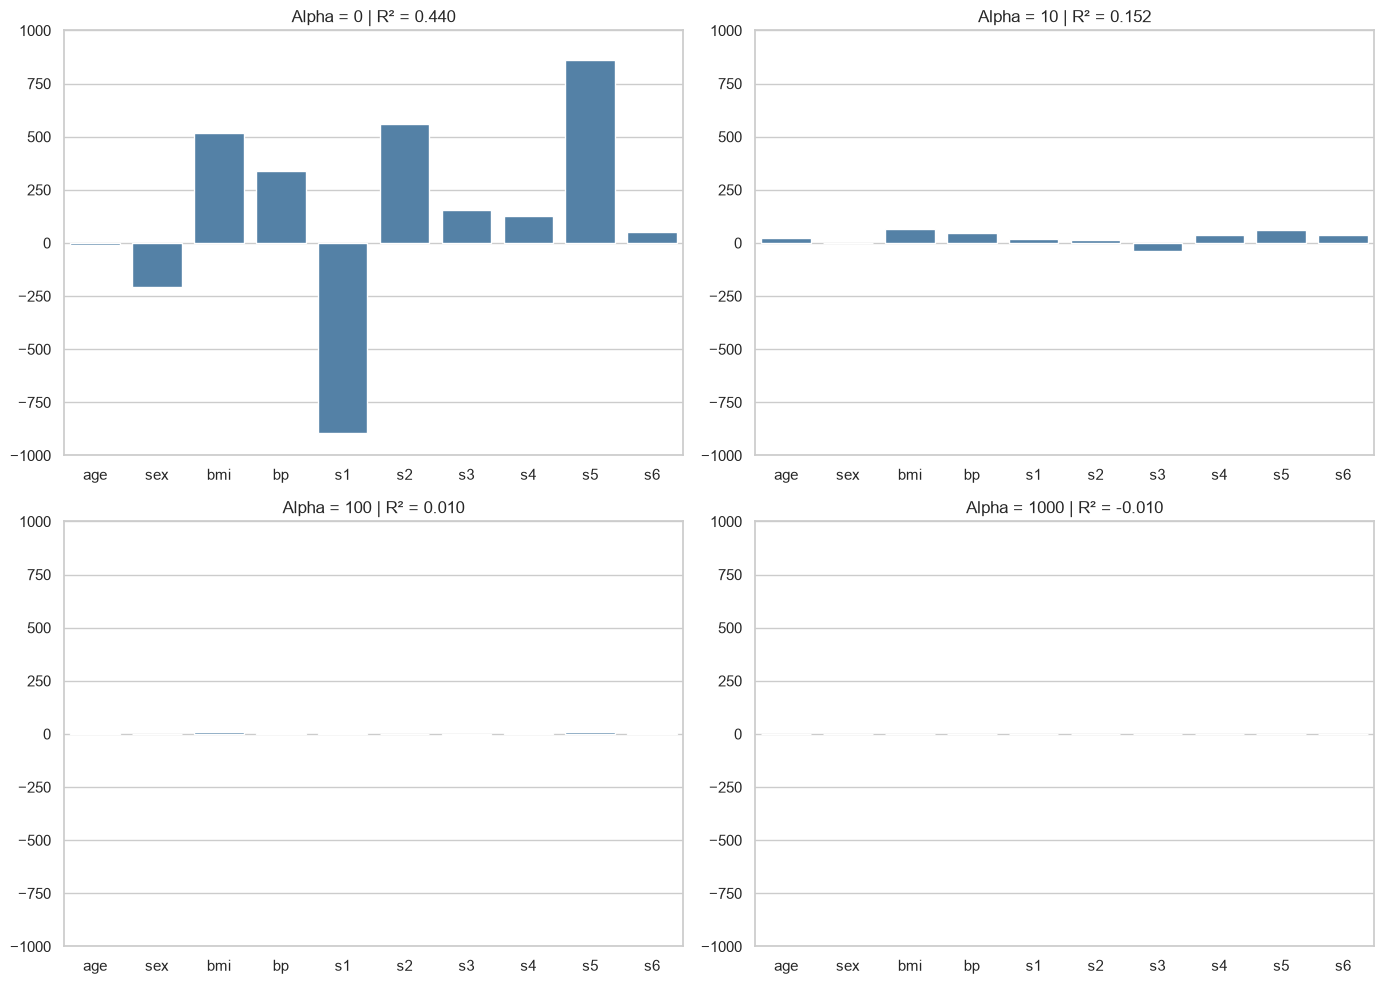

In [9]:
# Visualize coefficient shrinkage
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (alpha, coefs, r2) in enumerate(zip(alpha_values_discrete, coef_list, r2_list)):
    sns.barplot(x=feature_names, y=coefs, ax=axes[idx], color="steelblue")
    axes[idx].set_title(f'Alpha = {alpha} | R² = {r2:.3f}')
    axes[idx].set_ylim(-1000, 1000)

plt.tight_layout()
plt.show()

### **Key Revision Notes**
- **Alpha = 0** equates to standard Ordinary Least Squares (OLS) Linear Regression.
- As **Alpha increases**, the magnitude of all coefficients decreases steadily toward zero.
- **Extreme Alpha values** (e.g., 1000) over-penalize the model, severely degrading predictive performance (R² drops significantly).

### **2. Differential Shrinkage (Higher Coefficients Penalized More)**

**What it does**

Features with naturally larger coefficients experience a steeper and faster decay compared to features with smaller coefficients as the regularization strength increases.

**Why it is used**

Because the penalty is squared ($w^2$), a weight of 10 incurs a penalty of 100, while a weight of 1 incurs a penalty of 1. The optimization algorithm naturally prioritizes shrinking the largest weights first to minimize the overall loss function.

In [10]:
# Train Ridge across a continuous range of alphas to track coefficient paths
alpha_path_values = [0, 0.0001, 0.0005, 0.001, 0.005, 0.1, 0.5, 1, 5, 10]
coef_path_matrix = []

for alpha in alpha_path_values:
    ridge_path_model = Ridge(alpha=alpha)
    ridge_path_model.fit(X_train_d, y_train_d)
    coef_path_matrix.append(ridge_path_model.coef_)

coef_df = pd.DataFrame(coef_path_matrix, index=alpha_path_values, columns=feature_names)

findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmti10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


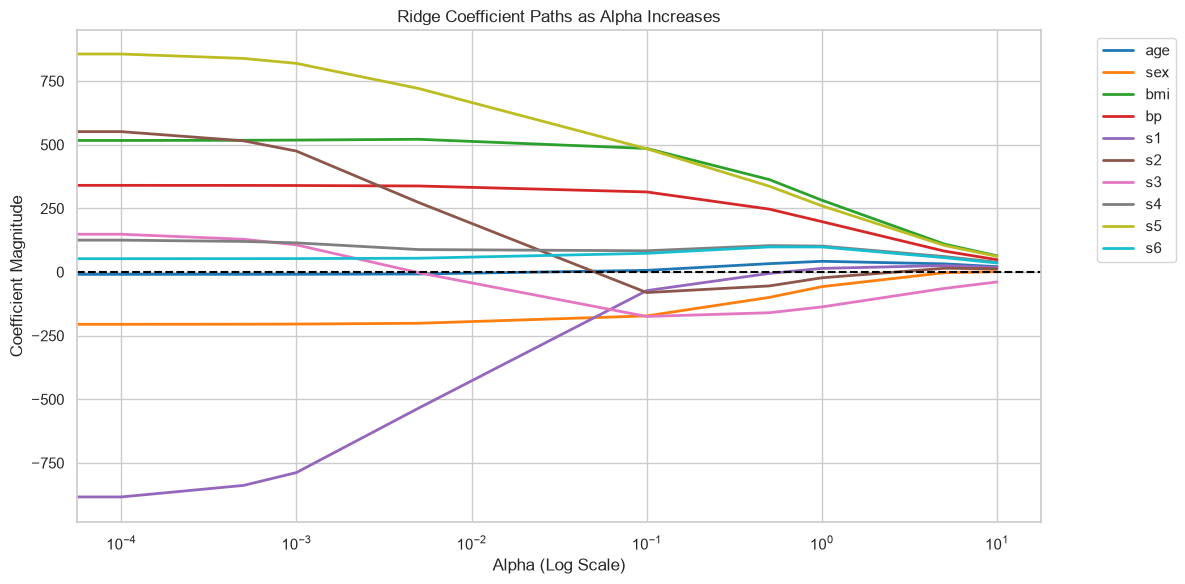

In [11]:
# Visualize Coefficient Paths
plt.figure(figsize=(12, 6))
sns.lineplot(data=coef_df, dashes=False, palette="tab10", linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)

plt.xscale('log') # Log scale emphasizes early rapid shrinkage
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Coefficient Magnitude')
plt.title('Ridge Coefficient Paths as Alpha Increases')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### **Key Revision Notes**
- **L2 Norm Mechanics:** The squaring of weights means outliers in feature importance are aggressively squashed.
- Notice on the graph how the largest initial weights (e.g., `s1`, `s5`) curve downward sharply, whereas smaller weights remain relatively stable until Alpha becomes very large.

### **3. Impact on Bias and Variance**

**What it does**

Regularization introduces intentional bias into the model to significantly reduce its variance.

**When it is useful**

When fitting complex models (like high-degree polynomials) that are prone to overfitting the training data. Increasing alpha stabilizes the model against unseen data.

In [12]:
# Generate noisy polynomial data
np.random.seed(42)
m = 100
X_poly = 5 * np.random.rand(m, 1) - 2
y_poly = 0.7 * X_poly ** 2 - 2 * X_poly + 3 + np.random.randn(m, 1)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y_poly, test_size=0.2, random_state=2)

# Force High Variance by using a high-degree polynomial (Degree=15)
poly_transformer = PolynomialFeatures(degree=15)
X_train_poly = poly_transformer.fit_transform(X_train_p)
X_test_poly = poly_transformer.transform(X_test_p)

In [13]:
# Evaluate Bias, Variance, and Expected Loss across alpha values
alpha_bv_range = np.linspace(0, 30, 50)
loss_history, bias_history, variance_history = [], [], []

for alpha in alpha_bv_range:
    ridge_bv = Ridge(alpha=alpha)
    
    # Calculate bias-variance decomposition
    avg_loss, avg_bias, avg_var = bias_variance_decomp(
        ridge_bv, X_train_poly, y_train_p.ravel(), X_test_poly, y_test_p.ravel(), 
        loss='mse',
        random_seed=123
    )
    
    loss_history.append(avg_loss)
    bias_history.append(avg_bias)
    variance_history.append(avg_var)

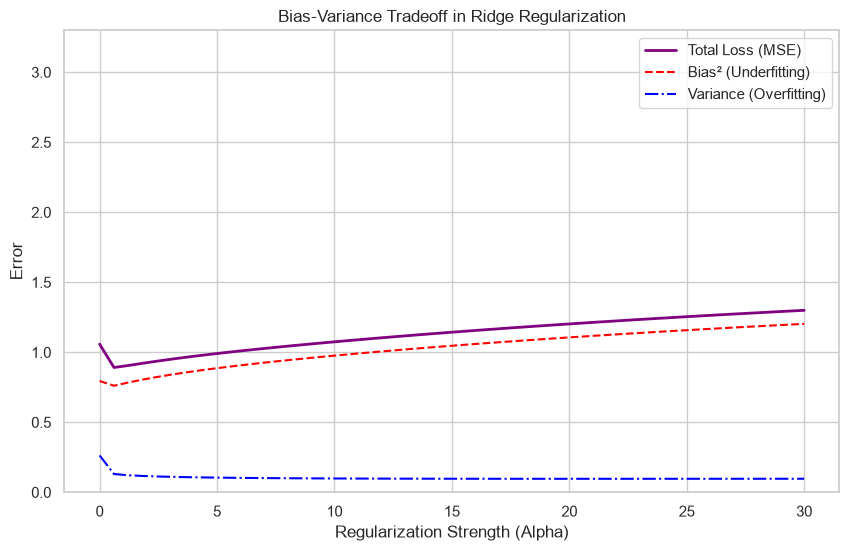

In [14]:
# Plot the Bias-Variance Tradeoff
plt.figure(figsize=(10, 6))
plt.plot(alpha_bv_range, loss_history, label='Total Loss (MSE)', color='purple', linewidth=2)
plt.plot(alpha_bv_range, bias_history, label='Bias² (Underfitting)', color='red', linestyle='--')
plt.plot(alpha_bv_range, variance_history, label='Variance (Overfitting)', color='blue', linestyle='-.')

plt.ylim(0, max(loss_history) + 2)
plt.xlabel('Regularization Strength (Alpha)')
plt.ylabel('Error')
plt.title('Bias-Variance Tradeoff in Ridge Regularization')
plt.legend()
plt.show()

### **Key Revision Notes**
- **Low Alpha:** Model captures noise (Overfitting). High Variance, Low Bias.
- **High Alpha:** Model becomes too simple (Underfitting). Low Variance, High Bias.
- **Sweet Spot:** The goal is to find the alpha where the sum of Bias² and Variance (Total Loss) is minimized.

### **4. Effect on the Loss Function Landscape**

**What it does**

Ridge transforms the optimization landscape by adding a quadratic penalty term to the base Mean Squared Error (MSE) curve. 

**Why it is useful**

It shifts the global minimum of the loss function closer to zero. It also makes the loss function strictly convex, ensuring a unique mathematical solution even when features are highly correlated.

In [15]:
# Create simple 1D dataset to visualize the loss landscape
X_1d, y_1d = make_regression(n_samples=100, n_features=1, n_informative=1, noise=20, random_state=13)

# Find OLS baseline intercept to isolate the weight parameter (m)
baseline_model = LinearRegression().fit(X_1d, y_1d)
baseline_intercept = baseline_model.intercept_

# Helper function to calculate Ridge Loss dynamically
def calculate_ridge_loss(weight, alpha):
    mse_loss = np.sum((y_1d - (weight * X_1d.ravel() + baseline_intercept)) ** 2)
    penalty = alpha * (weight ** 2)
    return mse_loss + penalty

weight_space = np.linspace(-45, 100, 100)
alpha_test_vals = [0, 10, 50, 100, 500]

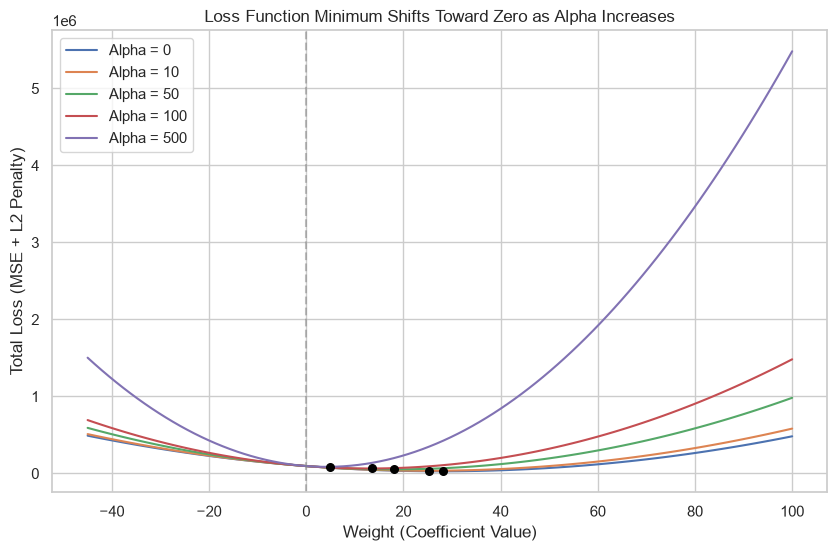

In [16]:
# Visualize Loss Function Transformation
plt.figure(figsize=(10, 6))

for alpha in alpha_test_vals:
    loss_curve = [calculate_ridge_loss(w, alpha) for w in weight_space]
    plt.plot(weight_space, loss_curve, label=f'Alpha = {alpha}')
    
    # Mark the minimum point of each curve
    min_weight = weight_space[np.argmin(loss_curve)]
    min_loss = np.min(loss_curve)
    plt.scatter(min_weight, min_loss, color='black', s=30, zorder=5)

plt.xlabel('Weight (Coefficient Value)')
plt.ylabel('Total Loss (MSE + L2 Penalty)')
plt.title('Loss Function Minimum Shifts Toward Zero as Alpha Increases')
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### **Key Revision Notes**
- The base parabola (Alpha = 0) represents the standard OLS loss function. The minimum is the standard best-fit weight.
- As Alpha increases, the parabola becomes steeper (more heavily penalized) and shifts to the left (closer to Weight = 0).
- The coefficient will approach, but conceptually never perfectly hit absolute zero (unlike Lasso/L1 regularization).